In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv', encoding='ISO-8859-1')

x = df['no2'].dropna().values.reshape(-1, 1)

a_r, b_r = 1.5, 1.5

z_real = x + a_r * np.sin(b_r * x)

z_mean, z_std = z_real.mean(), z_real.std()
z_scaled = (z_real - z_mean) / z_std
z_tensor = torch.FloatTensor(z_scaled)

/tmp/ipython-input-793867697.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', encoding='ISO-8859-1')


In [8]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

gen = Generator()
disc = Discriminator()
d_optimizer = optim.Adam(disc.parameters(), lr=0.0002)
g_optimizer = optim.Adam(gen.parameters(), lr=0.0002)
criterion = nn.BCELoss()

In [9]:
epochs = 5000
batch_size = 128

for epoch in range(epochs):
    idx = np.random.randint(0, z_tensor.size(0), batch_size)
    real_data = z_tensor[idx]

    noise = torch.randn(batch_size, 1)
    fake_data = gen(noise)

    d_real = disc(real_data)
    d_fake = disc(fake_data.detach())

    loss_d = criterion(d_real, torch.ones(batch_size, 1)) + \
             criterion(d_fake, torch.zeros(batch_size, 1))

    d_optimizer.zero_grad()
    loss_d.backward()
    d_optimizer.step()

    noise = torch.randn(batch_size, 1)
    fake_data = gen(noise)
    d_fake = disc(fake_data)

    loss_g = criterion(d_fake, torch.ones(batch_size, 1))

    g_optimizer.zero_grad()
    loss_g.backward()
    g_optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: D_loss: {loss_d.item():.4f}, G_loss: {loss_g.item():.4f}")

Epoch 0: D_loss: 1.4000, G_loss: 0.8211
Epoch 1000: D_loss: 1.3420, G_loss: 0.7291
Epoch 2000: D_loss: 1.3741, G_loss: 0.7153
Epoch 3000: D_loss: 1.3794, G_loss: 0.6824
Epoch 4000: D_loss: 1.4301, G_loss: 0.6537


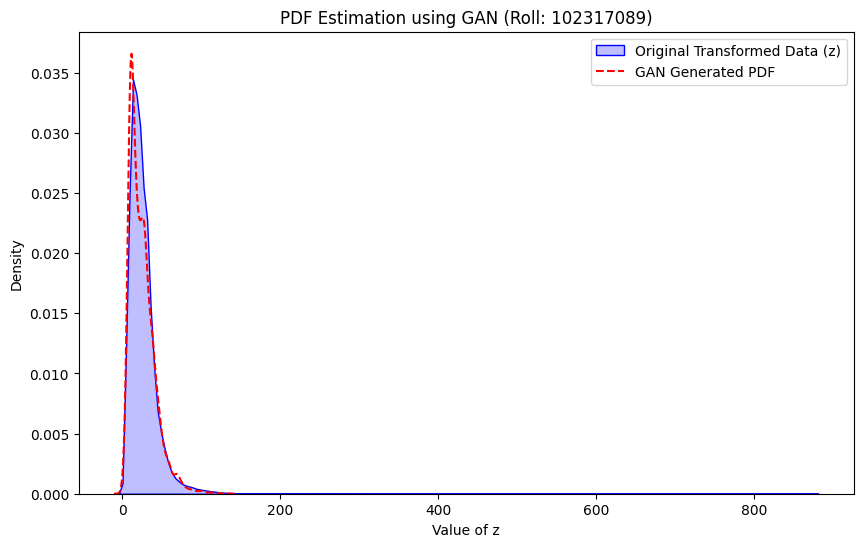

In [10]:
# Generate samples for evaluation
with torch.no_grad():
    test_noise = torch.randn(5000, 1)
    generated_z = gen(test_noise).numpy()

# Denormalize
generated_z_final = (generated_z * z_std) + z_mean

# Plotting
plt.figure(figsize=(10, 6))
sns.kdeplot(z_real.flatten(), label='Original Transformed Data (z)', fill=True, color="blue")
sns.kdeplot(generated_z_final.flatten(), label='GAN Generated PDF', color="red", linestyle="--")
plt.title(f"PDF Estimation using GAN (Roll: 102317089)")
plt.xlabel("Value of z")
plt.ylabel("Density")
plt.legend()
plt.show()